In [14]:
# ── Install if needed ─────────────────────────────────────────────
# !pip install biopython requests pandas

import os, time, warnings
import requests, numpy as np, pandas as pd
from pathlib import Path
from Bio.PDB import MMCIFParser, NeighborSearch
from Bio import BiopythonWarning
warnings.filterwarnings("ignore", category=BiopythonWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Metal  : Cobalt (CO)
Formula: Co
Found 200 structures containing CO
IDs: ['9EH3', '9MNV', '9MDB', '9MEO', '9EG2', '9EFY', '9EG0', '9EJV', '9ML0', '4A8I', '9EG5', '9EHN', '9MEP', '2GG2', '2GGC', '5IQN', '1O55', '1QXY', '9EG3', '9MEQ', '4GJZ', '2GG9', '2V3I', '7QF2', '7NYT', '1FD5', '1QV0', '1QV1', '2B3H', '2GZ5', '7QF3', '2GG7', '9EHQ', '1GWM', '3HHT', '6GPU', '7QF4', '9EJU', '1M5A', '4A8N', '4OB0', '4UWT', '6LV1', '6LV2', '6LV3', '6LV4', '6Z4N', '9KH8', '3V1D', '7O99', '4GJY', '3A4J', '3SXX', '7MK4', '2GG0', '7O9D', '6IIY', '6LZB', '1XEO', '4IKU', '4P7X', '4WWD', '6CQ3', '7QOU', '9GGX', '5VEJ', '5IQO', '4UOB', '4C4D', '4JKA', '5B7Y', '8PRR', '2XTS', '6DYC', '9GH1', '4ZHN', '3BFQ', '1OBX', '3KA8', '3TK2', '4A8L', '4ESM', '4Q3X', '4Q3Z', '6LZC', '6MR1', '9GH2', '6WFI', '7QF5', '9GGZ', '4WZX', '5Y9X', '6WF6', '1R6X', '1T5K', '1XCS', '3KA4', '3KA6', '4CV7', '4MNB', '4Q3W', '4Q3Y', '5VRK', '7QOV', '8SFB', '8SFC', '8SFK', '9KFU', '9MDG', '4A8R', '4D5I', '9D44', '2OPC', '5U0Q', '5YKA', '2GG3'

,pdb_id,metal_chain,metal_resseq,coord_number,n_aa,n_water,n_ligand,aa_list,donor_atoms,n_secondary
0,1FD5,A,21,6,0,5,1,,O;O;O;N7;O;O,14
1,1FD5,B,22,3,0,2,1,,O;N7;O,11
2,1GQI,A,1719,0,0,0,0,,,23
3,1GQI,A,1720,0,0,0,0,,,23
4,1GQI,A,1721,0,0,0,0,,,18
5,1GQI,A,1722,0,0,0,0,,,19
6,1GQI,B,1719,0,0,0,0,,,23
7,1GQI,B,1720,0,0,0,0,,,23
8,1GQI,B,1721,0,0,0,0,,,19
9,1GQI,B,1722,0,0,0,0,,,18



Saved: co_all_contacts.csv  |  co_sites_summary.csv
Contacts : 10196
Sites    : 414

Columns  : ['pdb_id', 'metal', 'metal_name', 'metal_chain', 'metal_resseq', 'nb_resname', 'nb_resseq', 'nb_chain', 'nb_atom', 'distance', 'category', 'sphere']


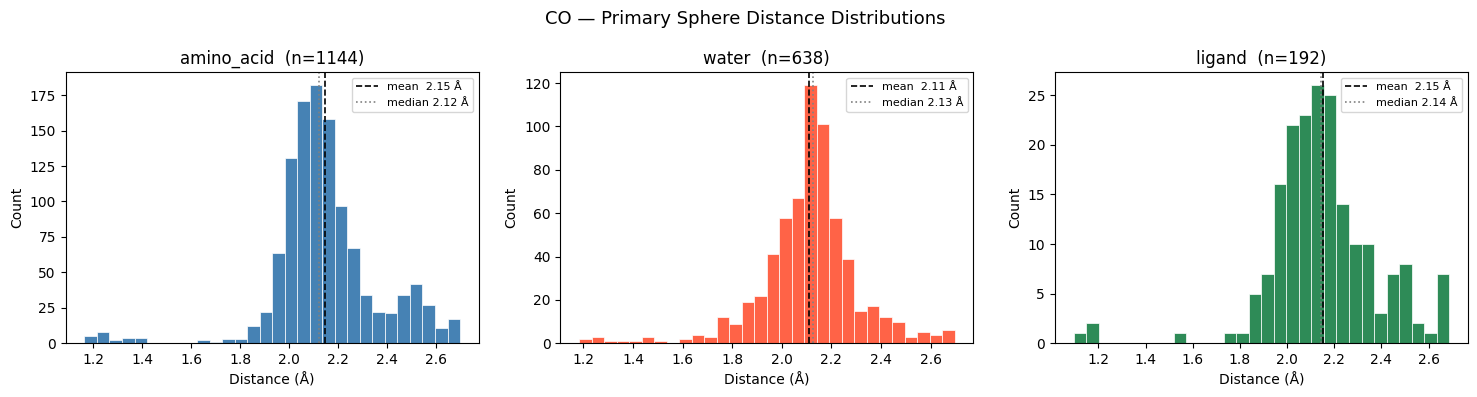

/tmp/ipykernel_3717128/1554671518.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_atom, labels=top_atoms, patch_artist=True,


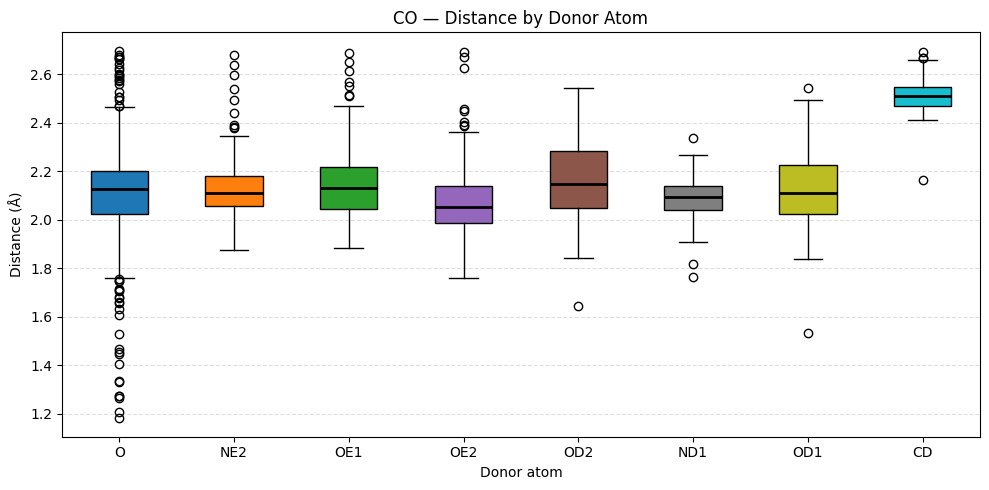

/tmp/ipykernel_3717128/1554671518.py:336: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_aa, labels=top_aa, patch_artist=True,


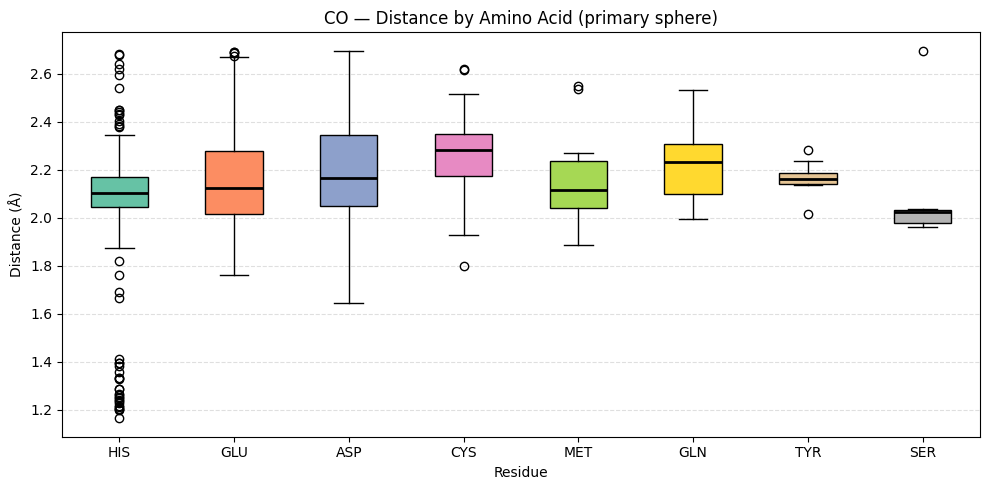

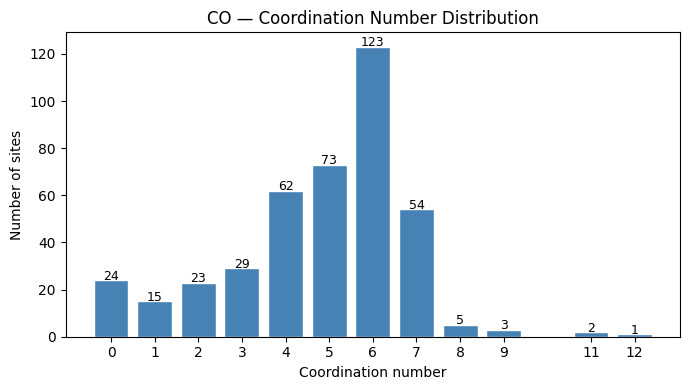


── Distance statistics by category (primary sphere) ──
            count   mean  median    std    min    max
category                                             
amino_acid   1144  2.146   2.123  0.216  1.165  2.696
ligand        192  2.154   2.142  0.232  1.095  2.687
metal           4  1.946   1.946  0.598  1.428  2.464
water         638  2.110   2.126  0.199  1.182  2.697

── Distance statistics by donor atom (top 10) ──
         count   mean  median    std
nb_atom                             
O          653  2.112   2.126  0.199
NE2        331  2.125   2.112  0.107
OE1        167  2.150   2.131  0.148
OE2        164  2.078   2.052  0.155
OD2        101  2.173   2.149  0.160
ND1         99  2.088   2.095  0.088
OD1         83  2.123   2.112  0.156
CD          63  2.517   2.512  0.079
CG          33  2.551   2.559  0.062
SG          30  2.249   2.215  0.170

── Distance statistics by amino acid (primary sphere) ──
            count   mean  median    std
nb_resname                  

In [15]:
# ═══════════════════════════════════════════════════════════════════
# CONFIG — change METAL_CODE to any metal you want
# ═══════════════════════════════════════════════════════════════════
METAL_CODE  = "CO"   # ← change to FE, CU, MG, CA, MN, CO, NI, etc.

N_STRUCTURES     = 200
RESOLUTION_MAX   = 2.0   # Å
PRIMARY_CUTOFF   = 2.7   # Å — direct coordination shell
SECONDARY_CUTOFF = 5.0   # Å — second sphere

# chemical formula symbol — must use standard capitalisation
FORMULA_MAP = {
    "ZN": "Zn", "FE": "Fe", "FE2": "Fe", "FE3": "Fe",
    "CU": "Cu", "CU1": "Cu", "CU2": "Cu",
    "MG": "Mg", "CA": "Ca", "MN": "Mn", "MN2": "Mn", "MN3": "Mn",
    "CO": "Co", "CO2": "Co", "NI": "Ni", "NI2": "Ni",
    "MO": "Mo", "W": "W",  "V": "V",   "CR": "Cr",
    "CD": "Cd", "HG": "Hg", "PT": "Pt", "AU": "Au", "AG": "Ag",
    "NA": "Na", "K": "K",  "RB": "Rb", "CS": "Cs",
    "BA": "Ba", "SR": "Sr", "LI": "Li",
}

METAL_NAMES = {
    "ZN": "Zinc",      "FE": "Iron",      "FE2": "Iron(II)",  "FE3": "Iron(III)",
    "CU": "Copper",    "CU1": "Copper(I)","CU2": "Copper(II)",
    "MG": "Magnesium", "CA": "Calcium",   "MN": "Manganese",
    "CO": "Cobalt",    "NI": "Nickel",    "MO": "Molybdenum",
    "W":  "Tungsten",  "V":  "Vanadium",  "CR": "Chromium",
    "CD": "Cadmium",   "HG": "Mercury",   "PT": "Platinum",
    "AU": "Gold",      "AG": "Silver",    "NA": "Sodium",
    "K":  "Potassium", "RB": "Rubidium",  "CS": "Cesium",
    "BA": "Barium",    "SR": "Strontium", "LI": "Lithium",
}

AMINO_ACIDS = {
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS",
    "ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL",
    "MSE","SEC","HYP","SEP","TPO","PTR",
}
WATERS = {"HOH","WAT","H2O","DOD"}

PDB_DIR = Path(f"{METAL_CODE.lower()}_pdbs")
PDB_DIR.mkdir(exist_ok=True)

metal_name = METAL_NAMES.get(METAL_CODE, METAL_CODE)
formula    = FORMULA_MAP.get(METAL_CODE, METAL_CODE.capitalize())
print(f"Metal  : {metal_name} ({METAL_CODE})")
print(f"Formula: {formula}")

# ═══════════════════════════════════════════════════════════════════
# 1. QUERY RCSB
# ═══════════════════════════════════════════════════════════════════
def get_pdb_ids(metal_code, formula, n=N_STRUCTURES, resolution=RESOLUTION_MAX):
    query = {
        "query": {
            "type": "group",
            "logical_operator": "and",
            "nodes": [
                {
                    "type": "terminal",
                    "service": "chemical",
                    "parameters": {
                        "value": formula,
                        "type": "formula",
                        "match_subset": False
                    }
                },
                {
                    "type": "terminal",
                    "service": "text",
                    "parameters": {
                        "attribute": "exptl.method",
                        "operator": "exact_match",
                        "value": "X-RAY DIFFRACTION"
                    }
                },
                {
                    "type": "terminal",
                    "service": "text",
                    "parameters": {
                        "attribute": "rcsb_entry_info.resolution_combined",
                        "operator": "less_or_equal",
                        "value": resolution
                    }
                }
            ]
        },
        "return_type": "entry",
        "request_options": {
            "paginate": {"start": 0, "rows": n},
            "sort": [{"sort_by": "rcsb_entry_info.resolution_combined",
                      "direction": "asc"}]
        }
    }
    resp = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query",
        json=query,
        headers={"Content-Type": "application/json"},
        timeout=30
    )
    if not resp.ok:
        print(f"API error {resp.status_code}:\n{resp.text[:400]}")
        return []
    ids = [h["identifier"] for h in resp.json().get("result_set", [])]
    print(f"Found {len(ids)} structures containing {metal_code}")
    return ids

pdb_ids = get_pdb_ids(METAL_CODE, formula)
print("IDs:", pdb_ids)

# ═══════════════════════════════════════════════════════════════════
# 2. DOWNLOAD
# ═══════════════════════════════════════════════════════════════════
def download_cif(pdb_id):
    dest = PDB_DIR / f"{pdb_id}.cif"
    if dest.exists():
        return dest
    r = requests.get(
        f"https://files.rcsb.org/download/{pdb_id.lower()}.cif",
        timeout=30
    )
    if r.ok:
        dest.write_bytes(r.content)
        return dest
    return None

print("\nDownloading…")
paths = {}
for i, pid in enumerate(pdb_ids, 1):
    p = download_cif(pid)
    if p:
        paths[pid] = p
        print(f"  [{i}/{len(pdb_ids)}] {pid} ✓")
    else:
        print(f"  [{i}/{len(pdb_ids)}] {pid} ✗ failed")
    time.sleep(0.05)
print(f"\nDownloaded {len(paths)} files → {PDB_DIR}/")

# ═══════════════════════════════════════════════════════════════════
# 3. PARSE + COORDINATION ANALYSIS
# ═══════════════════════════════════════════════════════════════════
_parser = MMCIFParser(QUIET=True)

def categorize(resname):
    if resname in AMINO_ACIDS: return "amino_acid"
    if resname in WATERS:      return "water"
    if resname == METAL_CODE:  return "metal"
    return "ligand"

def analyze(pdb_id, path, metal_code):
    try:
        struct = _parser.get_structure(pdb_id, str(path))
    except Exception as e:
        print(f"  Parse error {pdb_id}: {e}")
        return []

    all_atoms = list(struct.get_atoms())
    if not all_atoms:
        return []

    ns   = NeighborSearch(all_atoms)
    rows = []

    for model in struct:
        for chain in model:
            for res in chain:
                if res.get_resname().strip().upper() != metal_code:
                    continue
                for metal_atom in res:
                    try:
                        metal_coord = metal_atom.get_vector().get_array()
                    except Exception:
                        continue

                    for atom in ns.search(metal_coord, SECONDARY_CUTOFF):
                        p = atom.get_parent()
                        if p is None:
                            continue
                        rname = p.get_resname().strip().upper()
                        # skip self
                        if rname == metal_code and p.get_id()[1] == res.get_id()[1]:
                            continue
                        dist = float(np.linalg.norm(
                            atom.get_vector().get_array() - metal_coord))
                        rows.append({
                            "pdb_id":       pdb_id,
                            "metal":        metal_code,
                            "metal_name":   metal_name,
                            "metal_chain":  chain.get_id(),
                            "metal_resseq": res.get_id()[1],
                            "nb_resname":   rname,
                            "nb_resseq":    p.get_id()[1],
                            "nb_chain":     str(p.get_parent().get_id()
                                               if p.get_parent() else "?"),
                            "nb_atom":      atom.get_name().strip(),
                            "distance":     round(dist, 3),
                            "category":     categorize(rname),
                            "sphere":       "primary" if dist <= PRIMARY_CUTOFF
                                                      else "secondary",
                        })
    return rows

print("\nAnalysing metal sites…")
all_rows = []
for i, (pid, path) in enumerate(paths.items(), 1):
    rows = analyze(pid, path, METAL_CODE)
    all_rows.extend(rows)
    print(f"  [{i}/{len(paths)}] {pid} → {len(rows)} contacts")

df = pd.DataFrame(all_rows)
print(f"\nTotal coordination entries: {len(df)}")
df.head()

# ═══════════════════════════════════════════════════════════════════
# 4. SUMMARY
# ═══════════════════════════════════════════════════════════════════
primary = df[df["sphere"] == "primary"]

print(f"\n── {metal_name} coordination summary ──────────────────────")

print("\nCoordination number distribution:")
cn = (primary.groupby(["pdb_id","metal_chain","metal_resseq"])
      .size().reset_index(name="coord_number"))
print(cn["coord_number"].value_counts().sort_index().to_string())

print("\nTop coordinating amino acids:")
print(primary[primary["category"]=="amino_acid"]["nb_resname"]
      .value_counts().head(10).to_string())

print("\nTop donor atoms:")
print(primary["nb_atom"].value_counts().head(10).to_string())

print("\nPrimary sphere composition:")
print(primary["category"].value_counts().to_string())

# per-site summary table
def summarize(g):
    p = g[g["sphere"] == "primary"]
    return pd.Series({
        "coord_number": len(p),
        "n_aa":         (p["category"] == "amino_acid").sum(),
        "n_water":      (p["category"] == "water").sum(),
        "n_ligand":     (p["category"] == "ligand").sum(),
        "aa_list":      ";".join(p[p["category"] == "amino_acid"]["nb_resname"]),
        "donor_atoms":  ";".join(p["nb_atom"]),
        "n_secondary":  (g["sphere"] == "secondary").sum(),
    })

sites = (df.groupby(["pdb_id","metal_chain","metal_resseq"])
           .apply(summarize, include_groups=False)
           .reset_index())
print(f"\nTotal {metal_name} sites: {len(sites)}")
display(sites.head(10))

# ═══════════════════════════════════════════════════════════════════
# 5. SAVE
# ═══════════════════════════════════════════════════════════════════
df.to_csv(f"{METAL_CODE.lower()}_all_contacts.csv", index=False)
sites.to_csv(f"{METAL_CODE.lower()}_sites_summary.csv", index=False)
print(f"\nSaved: {METAL_CODE.lower()}_all_contacts.csv  |  {METAL_CODE.lower()}_sites_summary.csv")


# ═══════════════════════════════════════════════════════════════════
# LOAD
# ═══════════════════════════════════════════════════════════════════
#METAL_CODE = "CO"   # ← change to match what you ran

df    = pd.read_csv(f"{METAL_CODE.lower()}_all_contacts.csv")
sites = pd.read_csv(f"{METAL_CODE.lower()}_sites_summary.csv")

print(f"Contacts : {len(df)}")
print(f"Sites    : {len(sites)}")
print(f"\nColumns  : {list(df.columns)}")
df.head()

# ═══════════════════════════════════════════════════════════════════
# 1. DISTANCE DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════
primary = df[df["sphere"] == "primary"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"{METAL_CODE} — Primary Sphere Distance Distributions", fontsize=13)

categories = ["amino_acid", "water", "ligand"]
colors     = ["steelblue", "tomato", "seagreen"]

for ax, cat, col in zip(axes, categories, colors):
    data = primary[primary["category"] == cat]["distance"]
    if data.empty:
        ax.set_title(f"{cat}\n(no data)")
        continue
    ax.hist(data, bins=30, color=col, edgecolor="white", linewidth=0.5)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.2,
               label=f"mean  {data.mean():.2f} Å")
    ax.axvline(data.median(), color="gray",  linestyle=":",  linewidth=1.2,
               label=f"median {data.median():.2f} Å")
    ax.set_title(f"{cat}  (n={len(data)})")
    ax.set_xlabel("Distance (Å)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_distributions.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 2. DISTANCE BY DONOR ATOM TYPE
# ═══════════════════════════════════════════════════════════════════
top_atoms = primary["nb_atom"].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(10, 5))
data_by_atom = [primary[primary["nb_atom"] == a]["distance"].values
                for a in top_atoms]
bp = ax.boxplot(data_by_atom, labels=top_atoms, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"],
                        plt.cm.tab10(np.linspace(0, 1, len(top_atoms)))):
    patch.set_facecolor(color)
ax.set_title(f"{METAL_CODE} — Distance by Donor Atom")
ax.set_xlabel("Donor atom")
ax.set_ylabel("Distance (Å)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_by_atom.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 3. DISTANCE BY AMINO ACID
# ═══════════════════════════════════════════════════════════════════
aa_data = primary[primary["category"] == "amino_acid"]
top_aa  = aa_data["nb_resname"].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(10, 5))
data_by_aa = [aa_data[aa_data["nb_resname"] == aa]["distance"].values
              for aa in top_aa]
bp = ax.boxplot(data_by_aa, labels=top_aa, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"],
                        plt.cm.Set2(np.linspace(0, 1, len(top_aa)))):
    patch.set_facecolor(color)
ax.set_title(f"{METAL_CODE} — Distance by Amino Acid (primary sphere)")
ax.set_xlabel("Residue")
ax.set_ylabel("Distance (Å)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_by_aa.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 4. COORDINATION NUMBER DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
cn_counts = sites["coord_number"].value_counts().sort_index()
ax.bar(cn_counts.index, cn_counts.values, color="steelblue", edgecolor="white")
ax.set_title(f"{METAL_CODE} — Coordination Number Distribution")
ax.set_xlabel("Coordination number")
ax.set_ylabel("Number of sites")
ax.set_xticks(cn_counts.index)
for i, v in zip(cn_counts.index, cn_counts.values):
    ax.text(i, v + 0.2, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_coord_number.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 5. NUMERIC SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════
print(f"\n── Distance statistics by category (primary sphere) ──")
print(
    primary.groupby("category")["distance"]
    .agg(count="count", mean="mean", median="median",
         std="std", min="min", max="max")
    .round(3)
    .to_string()
)

print(f"\n── Distance statistics by donor atom (top 10) ──")
print(
    primary.groupby("nb_atom")["distance"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("count", ascending=False)
    .head(10)
    .round(3)
    .to_string()
)

print(f"\n── Distance statistics by amino acid (primary sphere) ──")
print(
    aa_data.groupby("nb_resname")["distance"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("count", ascending=False)
    .round(3)
    .to_string()
)

print(f"\n── Coordination number statistics ──")
print(sites["coord_number"].describe().round(2).to_string())

Metal  : Nickel (NI)
Formula: Ni
Found 200 structures containing NI
IDs: ['2UU8', '5JSK', '1XMK', '9AYN', '4RTZ', '5NFK', '5JIG', '3ZUC', '9FPI', '6Z8M', '9FPO', '4OMO', '5JSY', '6FPO', '6XX4', '6R4Z', '3ZQW', '6U1A', '6Z8J', '4WWF', '5ADU', '5FG6', '6RTP', '6H10', '4WWB', '6TL7', '6TTN', '5PLK', '5PLM', '5PLN', '5PLO', '5PLV', '5PMX', '5PN0', '5PNH', '5PNR', '5PNU', '6W1G', '5PHL', '3LAG', '5PHJ', '5PMZ', '3AYX', '5PIA', '5PJH', '5Q22', '6ETV', '9FPJ', '2XIO', '5PKH', '5PKI', '5PMW', '8ASO', '6RUC', '2BMO', '3HT1', '5AMH', '5JRD', '5LMM', '5Q7C', '5Q82', '6LV5', '6LV6', '6LV7', '6LV8', '6SZK', '7Y2R', '7Y2S', '7Y2T', '7Y2U', '7Y2V', '7Y2W', '5PL4', '5PNN', '5Q74', '6H0Y', '3AYZ', '4UQL', '5PKJ', '5PMT', '5A4I', '5PIW', '5PNB', '5Q8D', '5Q8X', '6H0W', '5PH3', '5PJ5', '5PMS', '5PNF', '5PH1', '5A4F', '5PHK', '5PIM', '5PKY', '5PN7', '5PNM', '5Q1O', '5Q78', '5Q7B', '6E85', '6SYO', '7O9E', '6ETT', '5Q7I', '5Q7M', '9FPK', '5PH4', '5PHX', '5PI8', '5PJU', '5PL0', '5PL3', '5PNK', '5Q7W', '6ETG'

,pdb_id,metal_chain,metal_resseq,coord_number,n_aa,n_water,n_ligand,aa_list,donor_atoms,n_secondary
0,1HYO,B,1008,4,1,3,0,GLY,O;O;O;O,8
1,1T6U,A,201,5,5,0,0,CYS;HIS;CYS;CYS;HIS,SG;N;SG;N;ND1,24
2,1T6U,B,202,5,5,0,0,CYS;CYS;HIS;CYS;HIS,SG;SG;ND1;N;N,23
3,1T6U,C,203,5,5,0,0,CYS;CYS;HIS;CYS;HIS,SG;N;N;SG;ND1,24
4,1T6U,D,204,4,4,0,0,HIS;CYS;CYS;CYS,N;N;SG;SG,25
5,1T6U,E,205,4,4,0,0,HIS;CYS;CYS;CYS,N;N;SG;SG,25
6,1T6U,F,206,4,4,0,0,HIS;CYS;CYS;CYS,N;N;SG;SG,24
7,1T6U,G,207,5,5,0,0,CYS;HIS;CYS;HIS;CYS,SG;ND1;SG;N;N,25
8,1T6U,H,208,4,4,0,0,CYS;CYS;CYS;HIS,SG;N;SG;N,23
9,1T6U,I,209,4,4,0,0,CYS;HIS;CYS;CYS,SG;N;SG;N,26



Saved: ni_all_contacts.csv  |  ni_sites_summary.csv
Contacts : 7839
Sites    : 263

Columns  : ['pdb_id', 'metal', 'metal_name', 'metal_chain', 'metal_resseq', 'nb_resname', 'nb_resseq', 'nb_chain', 'nb_atom', 'distance', 'category', 'sphere']


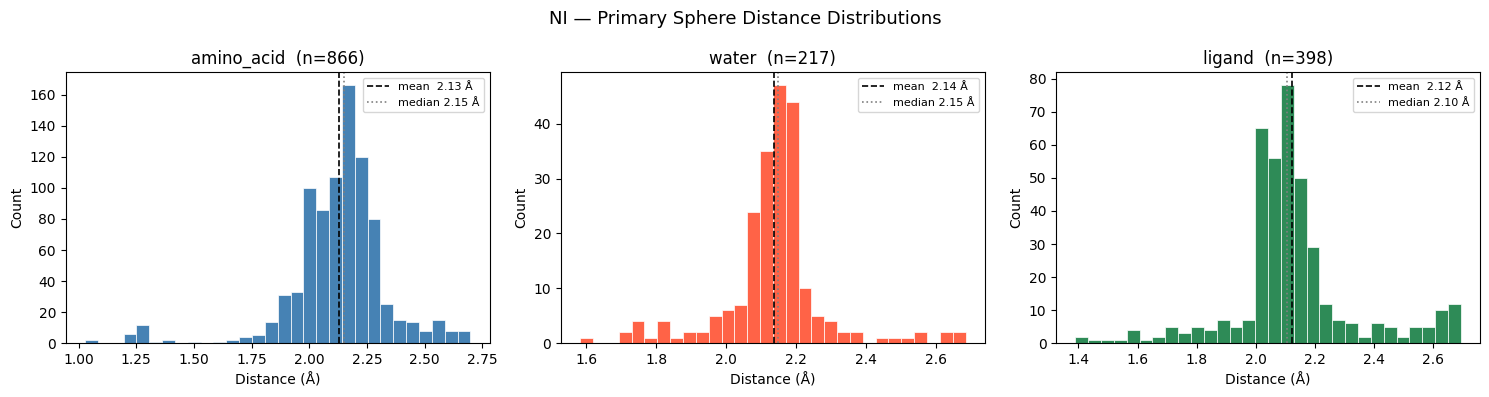

/tmp/ipykernel_3717128/225485800.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_atom, labels=top_atoms, patch_artist=True,


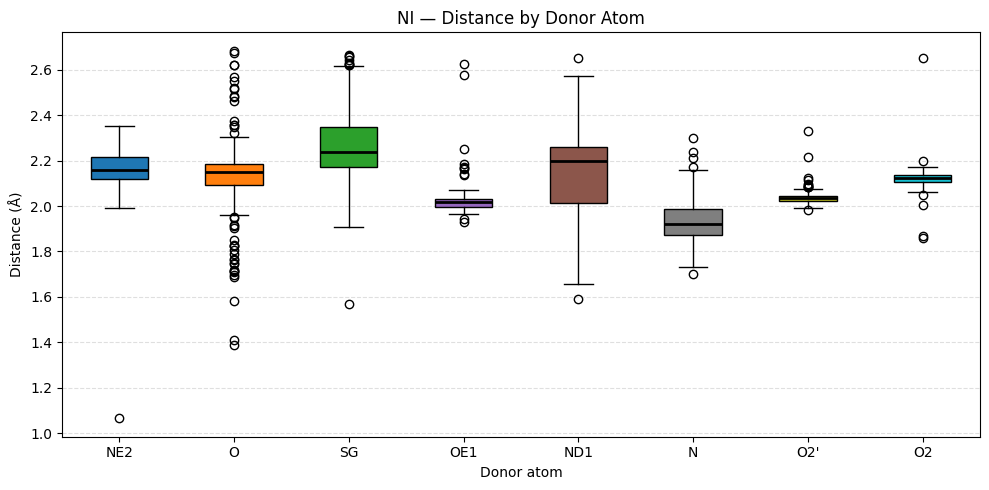

/tmp/ipykernel_3717128/225485800.py:336: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_aa, labels=top_aa, patch_artist=True,


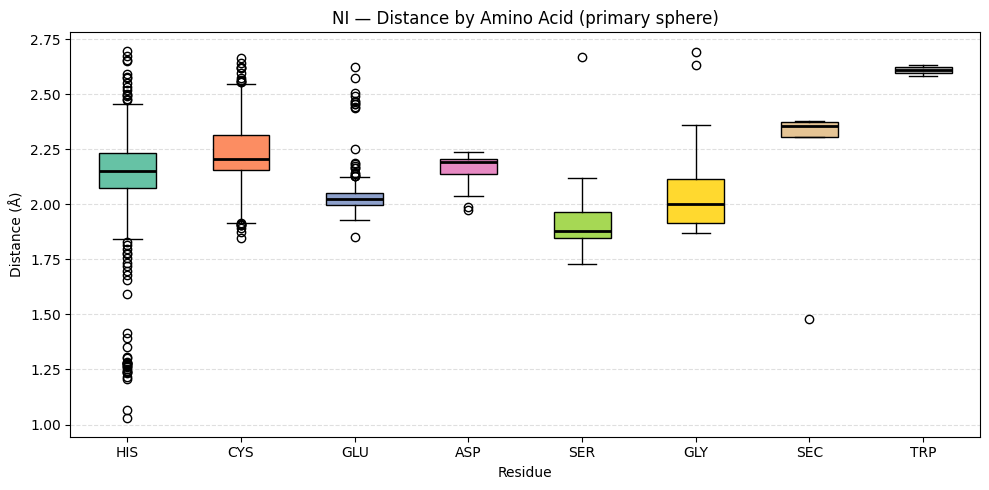

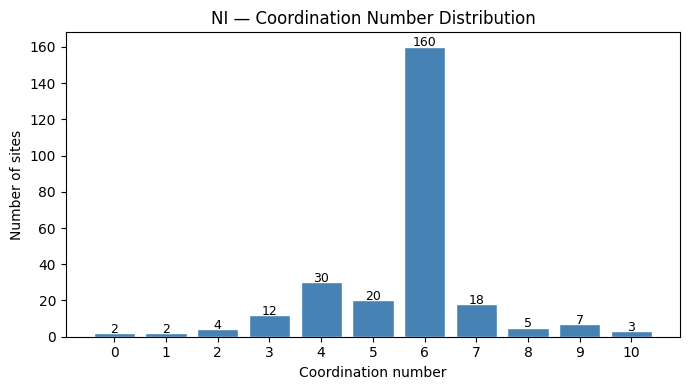


── Distance statistics by category (primary sphere) ──
            count   mean  median    std    min    max
category                                             
amino_acid    866  2.127   2.149  0.217  1.028  2.698
ligand        398  2.123   2.105  0.212  1.390  2.693
metal           4  1.120   1.120  0.203  0.945  1.296
water         217  2.136   2.149  0.149  1.583  2.684

── Distance statistics by donor atom (top 10) ──
         count   mean  median    std
nb_atom                             
NE2        328  2.165   2.160  0.094
O          227  2.126   2.148  0.175
SG         160  2.273   2.239  0.173
OE1         98  2.035   2.018  0.096
ND1         84  2.141   2.198  0.198
N           83  1.942   1.919  0.113
O2'         79  2.044   2.034  0.046
O2          76  2.122   2.125  0.079
OD2         35  2.185   2.196  0.047
O1          30  2.119   2.115  0.186

── Distance statistics by amino acid (primary sphere) ──
            count   mean  median    std
nb_resname                  

In [16]:
# ═══════════════════════════════════════════════════════════════════
# CONFIG — change METAL_CODE to any metal you want
# ═══════════════════════════════════════════════════════════════════
METAL_CODE  = "NI"   # ← change to FE, CU, MG, CA, MN, CO, NI, etc.

N_STRUCTURES     = 200
RESOLUTION_MAX   = 2.0   # Å
PRIMARY_CUTOFF   = 2.7   # Å — direct coordination shell
SECONDARY_CUTOFF = 5.0   # Å — second sphere

# chemical formula symbol — must use standard capitalisation
FORMULA_MAP = {
    "ZN": "Zn", "FE": "Fe", "FE2": "Fe", "FE3": "Fe",
    "CU": "Cu", "CU1": "Cu", "CU2": "Cu",
    "MG": "Mg", "CA": "Ca", "MN": "Mn", "MN2": "Mn", "MN3": "Mn",
    "CO": "Co", "CO2": "Co", "NI": "Ni", "NI2": "Ni",
    "MO": "Mo", "W": "W",  "V": "V",   "CR": "Cr",
    "CD": "Cd", "HG": "Hg", "PT": "Pt", "AU": "Au", "AG": "Ag",
    "NA": "Na", "K": "K",  "RB": "Rb", "CS": "Cs",
    "BA": "Ba", "SR": "Sr", "LI": "Li",
}

METAL_NAMES = {
    "ZN": "Zinc",      "FE": "Iron",      "FE2": "Iron(II)",  "FE3": "Iron(III)",
    "CU": "Copper",    "CU1": "Copper(I)","CU2": "Copper(II)",
    "MG": "Magnesium", "CA": "Calcium",   "MN": "Manganese",
    "CO": "Cobalt",    "NI": "Nickel",    "MO": "Molybdenum",
    "W":  "Tungsten",  "V":  "Vanadium",  "CR": "Chromium",
    "CD": "Cadmium",   "HG": "Mercury",   "PT": "Platinum",
    "AU": "Gold",      "AG": "Silver",    "NA": "Sodium",
    "K":  "Potassium", "RB": "Rubidium",  "CS": "Cesium",
    "BA": "Barium",    "SR": "Strontium", "LI": "Lithium",
}

AMINO_ACIDS = {
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS",
    "ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL",
    "MSE","SEC","HYP","SEP","TPO","PTR",
}
WATERS = {"HOH","WAT","H2O","DOD"}

PDB_DIR = Path(f"{METAL_CODE.lower()}_pdbs")
PDB_DIR.mkdir(exist_ok=True)

metal_name = METAL_NAMES.get(METAL_CODE, METAL_CODE)
formula    = FORMULA_MAP.get(METAL_CODE, METAL_CODE.capitalize())
print(f"Metal  : {metal_name} ({METAL_CODE})")
print(f"Formula: {formula}")

# ═══════════════════════════════════════════════════════════════════
# 1. QUERY RCSB
# ═══════════════════════════════════════════════════════════════════
def get_pdb_ids(metal_code, formula, n=N_STRUCTURES, resolution=RESOLUTION_MAX):
    query = {
        "query": {
            "type": "group",
            "logical_operator": "and",
            "nodes": [
                {
                    "type": "terminal",
                    "service": "chemical",
                    "parameters": {
                        "value": formula,
                        "type": "formula",
                        "match_subset": False
                    }
                },
                {
                    "type": "terminal",
                    "service": "text",
                    "parameters": {
                        "attribute": "exptl.method",
                        "operator": "exact_match",
                        "value": "X-RAY DIFFRACTION"
                    }
                },
                {
                    "type": "terminal",
                    "service": "text",
                    "parameters": {
                        "attribute": "rcsb_entry_info.resolution_combined",
                        "operator": "less_or_equal",
                        "value": resolution
                    }
                }
            ]
        },
        "return_type": "entry",
        "request_options": {
            "paginate": {"start": 0, "rows": n},
            "sort": [{"sort_by": "rcsb_entry_info.resolution_combined",
                      "direction": "asc"}]
        }
    }
    resp = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query",
        json=query,
        headers={"Content-Type": "application/json"},
        timeout=30
    )
    if not resp.ok:
        print(f"API error {resp.status_code}:\n{resp.text[:400]}")
        return []
    ids = [h["identifier"] for h in resp.json().get("result_set", [])]
    print(f"Found {len(ids)} structures containing {metal_code}")
    return ids

pdb_ids = get_pdb_ids(METAL_CODE, formula)
print("IDs:", pdb_ids)

# ═══════════════════════════════════════════════════════════════════
# 2. DOWNLOAD
# ═══════════════════════════════════════════════════════════════════
def download_cif(pdb_id):
    dest = PDB_DIR / f"{pdb_id}.cif"
    if dest.exists():
        return dest
    r = requests.get(
        f"https://files.rcsb.org/download/{pdb_id.lower()}.cif",
        timeout=30
    )
    if r.ok:
        dest.write_bytes(r.content)
        return dest
    return None

print("\nDownloading…")
paths = {}
for i, pid in enumerate(pdb_ids, 1):
    p = download_cif(pid)
    if p:
        paths[pid] = p
        print(f"  [{i}/{len(pdb_ids)}] {pid} ✓")
    else:
        print(f"  [{i}/{len(pdb_ids)}] {pid} ✗ failed")
    time.sleep(0.05)
print(f"\nDownloaded {len(paths)} files → {PDB_DIR}/")

# ═══════════════════════════════════════════════════════════════════
# 3. PARSE + COORDINATION ANALYSIS
# ═══════════════════════════════════════════════════════════════════
_parser = MMCIFParser(QUIET=True)

def categorize(resname):
    if resname in AMINO_ACIDS: return "amino_acid"
    if resname in WATERS:      return "water"
    if resname == METAL_CODE:  return "metal"
    return "ligand"

def analyze(pdb_id, path, metal_code):
    try:
        struct = _parser.get_structure(pdb_id, str(path))
    except Exception as e:
        print(f"  Parse error {pdb_id}: {e}")
        return []

    all_atoms = list(struct.get_atoms())
    if not all_atoms:
        return []

    ns   = NeighborSearch(all_atoms)
    rows = []

    for model in struct:
        for chain in model:
            for res in chain:
                if res.get_resname().strip().upper() != metal_code:
                    continue
                for metal_atom in res:
                    try:
                        metal_coord = metal_atom.get_vector().get_array()
                    except Exception:
                        continue

                    for atom in ns.search(metal_coord, SECONDARY_CUTOFF):
                        p = atom.get_parent()
                        if p is None:
                            continue
                        rname = p.get_resname().strip().upper()
                        # skip self
                        if rname == metal_code and p.get_id()[1] == res.get_id()[1]:
                            continue
                        dist = float(np.linalg.norm(
                            atom.get_vector().get_array() - metal_coord))
                        rows.append({
                            "pdb_id":       pdb_id,
                            "metal":        metal_code,
                            "metal_name":   metal_name,
                            "metal_chain":  chain.get_id(),
                            "metal_resseq": res.get_id()[1],
                            "nb_resname":   rname,
                            "nb_resseq":    p.get_id()[1],
                            "nb_chain":     str(p.get_parent().get_id()
                                               if p.get_parent() else "?"),
                            "nb_atom":      atom.get_name().strip(),
                            "distance":     round(dist, 3),
                            "category":     categorize(rname),
                            "sphere":       "primary" if dist <= PRIMARY_CUTOFF
                                                      else "secondary",
                        })
    return rows

print("\nAnalysing metal sites…")
all_rows = []
for i, (pid, path) in enumerate(paths.items(), 1):
    rows = analyze(pid, path, METAL_CODE)
    all_rows.extend(rows)
    print(f"  [{i}/{len(paths)}] {pid} → {len(rows)} contacts")

df = pd.DataFrame(all_rows)
print(f"\nTotal coordination entries: {len(df)}")
df.head()

# ═══════════════════════════════════════════════════════════════════
# 4. SUMMARY
# ═══════════════════════════════════════════════════════════════════
primary = df[df["sphere"] == "primary"]

print(f"\n── {metal_name} coordination summary ──────────────────────")

print("\nCoordination number distribution:")
cn = (primary.groupby(["pdb_id","metal_chain","metal_resseq"])
      .size().reset_index(name="coord_number"))
print(cn["coord_number"].value_counts().sort_index().to_string())

print("\nTop coordinating amino acids:")
print(primary[primary["category"]=="amino_acid"]["nb_resname"]
      .value_counts().head(10).to_string())

print("\nTop donor atoms:")
print(primary["nb_atom"].value_counts().head(10).to_string())

print("\nPrimary sphere composition:")
print(primary["category"].value_counts().to_string())

# per-site summary table
def summarize(g):
    p = g[g["sphere"] == "primary"]
    return pd.Series({
        "coord_number": len(p),
        "n_aa":         (p["category"] == "amino_acid").sum(),
        "n_water":      (p["category"] == "water").sum(),
        "n_ligand":     (p["category"] == "ligand").sum(),
        "aa_list":      ";".join(p[p["category"] == "amino_acid"]["nb_resname"]),
        "donor_atoms":  ";".join(p["nb_atom"]),
        "n_secondary":  (g["sphere"] == "secondary").sum(),
    })

sites = (df.groupby(["pdb_id","metal_chain","metal_resseq"])
           .apply(summarize, include_groups=False)
           .reset_index())
print(f"\nTotal {metal_name} sites: {len(sites)}")
display(sites.head(10))

# ═══════════════════════════════════════════════════════════════════
# 5. SAVE
# ═══════════════════════════════════════════════════════════════════
df.to_csv(f"{METAL_CODE.lower()}_all_contacts.csv", index=False)
sites.to_csv(f"{METAL_CODE.lower()}_sites_summary.csv", index=False)
print(f"\nSaved: {METAL_CODE.lower()}_all_contacts.csv  |  {METAL_CODE.lower()}_sites_summary.csv")


# ═══════════════════════════════════════════════════════════════════
# LOAD
# ═══════════════════════════════════════════════════════════════════
#METAL_CODE = "CO"   # ← change to match what you ran

df    = pd.read_csv(f"{METAL_CODE.lower()}_all_contacts.csv")
sites = pd.read_csv(f"{METAL_CODE.lower()}_sites_summary.csv")

print(f"Contacts : {len(df)}")
print(f"Sites    : {len(sites)}")
print(f"\nColumns  : {list(df.columns)}")
df.head()

# ═══════════════════════════════════════════════════════════════════
# 1. DISTANCE DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════
primary = df[df["sphere"] == "primary"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"{METAL_CODE} — Primary Sphere Distance Distributions", fontsize=13)

categories = ["amino_acid", "water", "ligand"]
colors     = ["steelblue", "tomato", "seagreen"]

for ax, cat, col in zip(axes, categories, colors):
    data = primary[primary["category"] == cat]["distance"]
    if data.empty:
        ax.set_title(f"{cat}\n(no data)")
        continue
    ax.hist(data, bins=30, color=col, edgecolor="white", linewidth=0.5)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.2,
               label=f"mean  {data.mean():.2f} Å")
    ax.axvline(data.median(), color="gray",  linestyle=":",  linewidth=1.2,
               label=f"median {data.median():.2f} Å")
    ax.set_title(f"{cat}  (n={len(data)})")
    ax.set_xlabel("Distance (Å)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_distributions.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 2. DISTANCE BY DONOR ATOM TYPE
# ═══════════════════════════════════════════════════════════════════
top_atoms = primary["nb_atom"].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(10, 5))
data_by_atom = [primary[primary["nb_atom"] == a]["distance"].values
                for a in top_atoms]
bp = ax.boxplot(data_by_atom, labels=top_atoms, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"],
                        plt.cm.tab10(np.linspace(0, 1, len(top_atoms)))):
    patch.set_facecolor(color)
ax.set_title(f"{METAL_CODE} — Distance by Donor Atom")
ax.set_xlabel("Donor atom")
ax.set_ylabel("Distance (Å)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_by_atom.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 3. DISTANCE BY AMINO ACID
# ═══════════════════════════════════════════════════════════════════
aa_data = primary[primary["category"] == "amino_acid"]
top_aa  = aa_data["nb_resname"].value_counts().head(8).index

fig, ax = plt.subplots(figsize=(10, 5))
data_by_aa = [aa_data[aa_data["nb_resname"] == aa]["distance"].values
              for aa in top_aa]
bp = ax.boxplot(data_by_aa, labels=top_aa, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"],
                        plt.cm.Set2(np.linspace(0, 1, len(top_aa)))):
    patch.set_facecolor(color)
ax.set_title(f"{METAL_CODE} — Distance by Amino Acid (primary sphere)")
ax.set_xlabel("Residue")
ax.set_ylabel("Distance (Å)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_distance_by_aa.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 4. COORDINATION NUMBER DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
cn_counts = sites["coord_number"].value_counts().sort_index()
ax.bar(cn_counts.index, cn_counts.values, color="steelblue", edgecolor="white")
ax.set_title(f"{METAL_CODE} — Coordination Number Distribution")
ax.set_xlabel("Coordination number")
ax.set_ylabel("Number of sites")
ax.set_xticks(cn_counts.index)
for i, v in zip(cn_counts.index, cn_counts.values):
    ax.text(i, v + 0.2, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{METAL_CODE.lower()}_coord_number.png", dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════
# 5. NUMERIC SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════
print(f"\n── Distance statistics by category (primary sphere) ──")
print(
    primary.groupby("category")["distance"]
    .agg(count="count", mean="mean", median="median",
         std="std", min="min", max="max")
    .round(3)
    .to_string()
)

print(f"\n── Distance statistics by donor atom (top 10) ──")
print(
    primary.groupby("nb_atom")["distance"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("count", ascending=False)
    .head(10)
    .round(3)
    .to_string()
)

print(f"\n── Distance statistics by amino acid (primary sphere) ──")
print(
    aa_data.groupby("nb_resname")["distance"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("count", ascending=False)
    .round(3)
    .to_string()
)

print(f"\n── Coordination number statistics ──")
print(sites["coord_number"].describe().round(2).to_string())